In [8]:
import pandas as pd
import importlib
import process_utils as pu
importlib.reload(pu)

<module 'process_utils' from '/home/sam/Downloads/gh/TSCIL-AL/result/process_utils.py'>

In [9]:
AL_SETUP = {
    'HAR': (3,300),
    'WISDM': (5,40),
    'UWAVE' : (3,25)
}

In [10]:
DATASET = 'HAR'

AL_TOTAL = AL_SETUP[DATASET][0]
AL_BUDGET = AL_SETUP[DATASET][1]

In [11]:
filtered_files = pu.get_filtered_files([DATASET], [AL_TOTAL])
print("Filtered Files:\t", filtered_files)
pu.generate_score_files(filtered_files)

Filtered Files:	 ['har/Random_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-entropy_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-margin_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-entropy_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-margin_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-lc_ASER_cycle_3_per_300_har.csv', 'har/TypiClust_ER_cycle_3_per_300_har.csv', 'har/TypiClust_ASER_cycle_3_per_300_har.csv', 'har/Random_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-lc_ER_cycle_3_per_300_har.csv']


## Uncertainty and Random

In [12]:
uncert_la = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'learning_accuracy')
uncert_la.style.apply(pu.highlight_max, axis=1).format(precision=2)

,cycle,task,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,0,77.02,77.02,77.02,77.02,77.02,77.02,77.02,77.02
1,0,1,77.57,83.52,77.57,79.70,79.53,84.01,78.05,83.52
2,0,2,87.11,86.40,87.92,86.13,87.89,84.44,89.73,87.24
3,1,0,85.31,85.31,85.31,82.98,82.98,85.31,85.31,85.31
4,1,1,88.42,90.91,87.67,85.64,87.62,88.42,88.06,94.36
5,1,2,91.51,86.01,91.45,86.02,90.22,87.61,88.10,91.80
6,2,0,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
7,2,1,91.38,93.55,92.95,91.71,94.55,89.28,90.97,95.57
8,2,2,92.54,87.94,90.88,89.13,91.96,88.21,89.40,92.53


['Random-ER', 'Random-ASER']


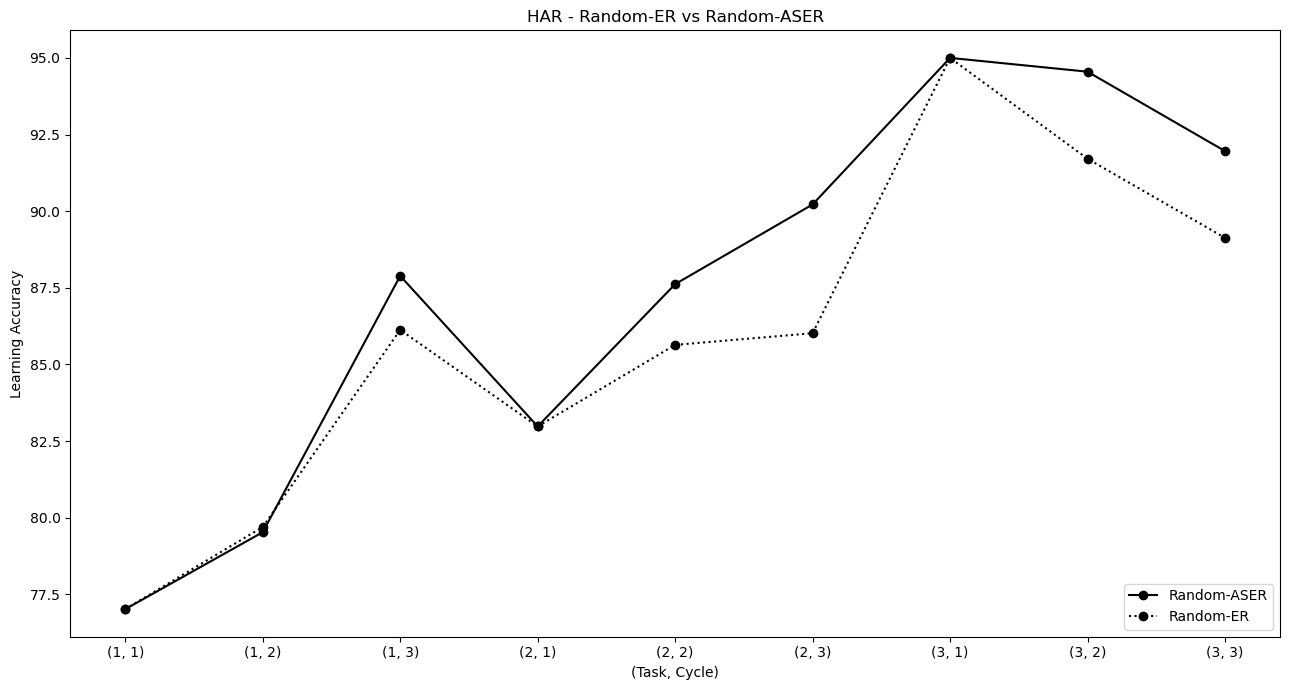

In [13]:
dic = uncert_la[['cycle', 'task', 'Random-ER', 'Random-ASER']]

pu.plot_progress(
    df=dic, 
    loc='lower right',
    title=f"{DATASET} - Random-ER vs Random-ASER",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


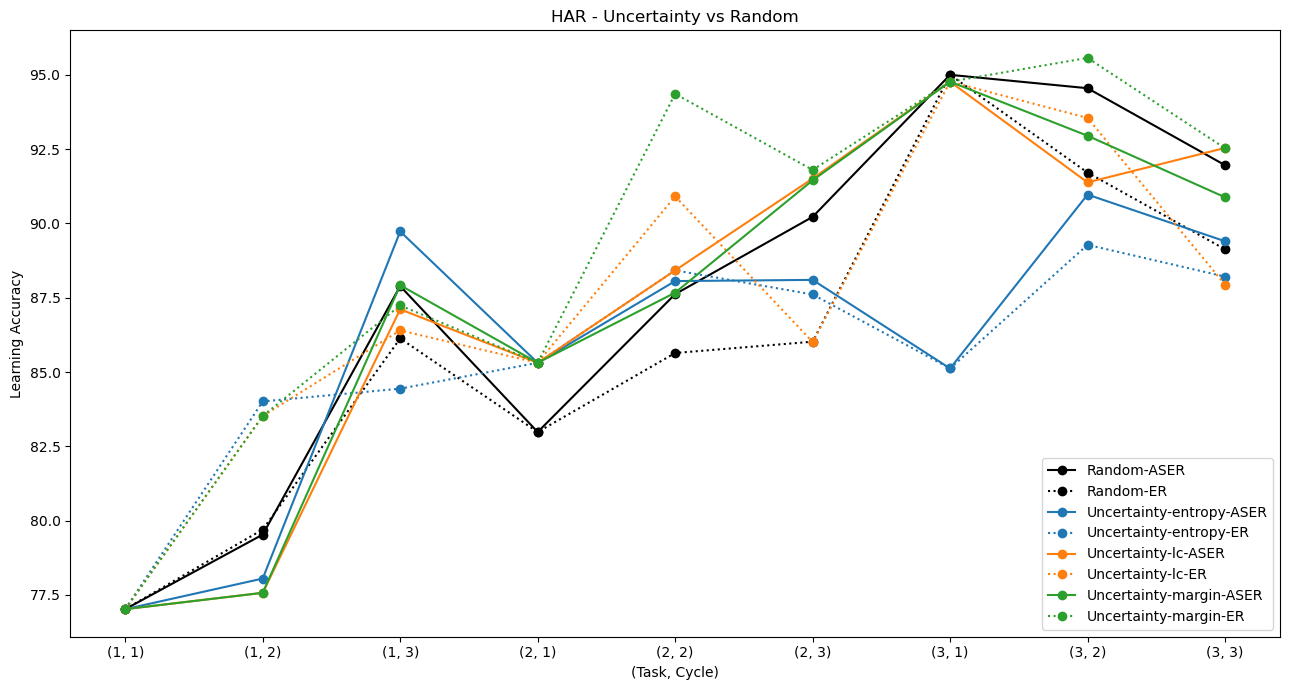

In [14]:
pu.plot_progress(
    df=uncert_la, 
    loc='lower right',
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

In [15]:
uncert_aa = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'average_accuracy')
uncert_aa.style.apply(pu.highlight_max, axis=1).format(precision=2)

,cycle,task,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,0,77.02,77.02,77.02,77.02,77.02,77.02,77.02,77.02
1,0,1,80.34,84.57,80.34,78.22,78.84,82.56,78.90,84.57
2,0,2,58.21,67.20,60.94,68.41,64.28,67.19,60.76,68.61
3,1,0,85.31,85.31,85.31,82.98,82.98,85.31,85.31,85.31
4,1,1,80.60,78.78,80.05,77.05,82.84,82.84,80.13,75.11
5,1,2,55.81,69.69,62.18,69.86,61.89,65.86,60.68,70.99
6,2,0,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
7,2,1,78.85,77.33,73.76,79.29,84.32,75.86,80.08,76.78
8,2,2,57.46,72.51,62.57,67.83,63.01,69.54,61.10,69.83


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


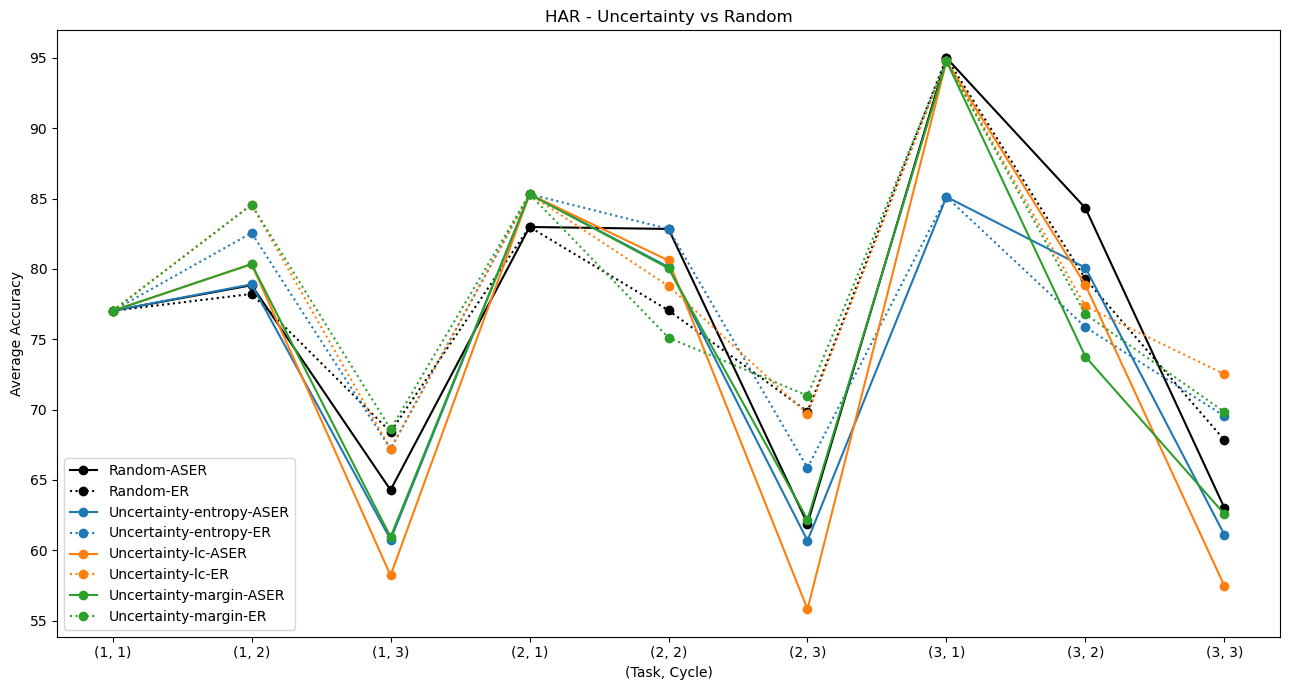

In [16]:
pu.plot_progress(
    df=uncert_aa,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Average Accuracy")

['AA_Random-ASER', 'LA_Random-ER']


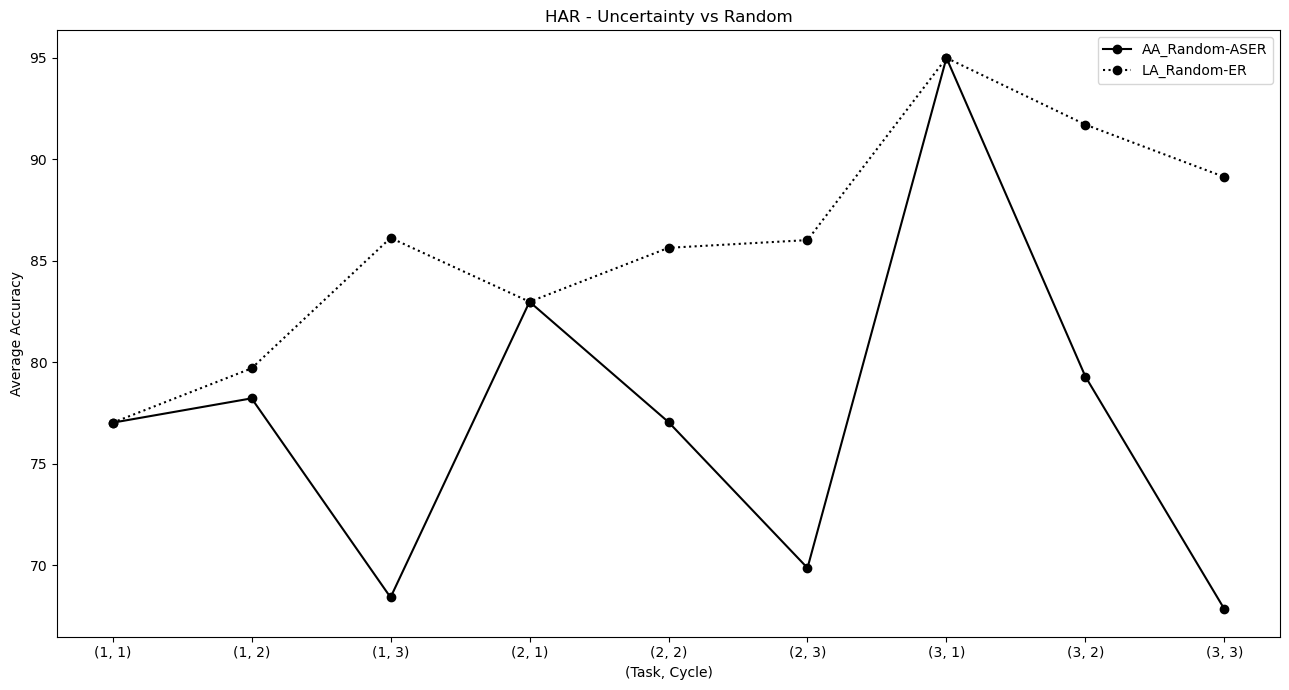

In [17]:
# Create dataframes with prefixes
aa_df = uncert_aa[['task','cycle', 'Random-ER']].copy()
la_df = uncert_la[['Random-ER']].copy()

aa_df.rename(columns={'Random-ER': 'AA_Random-ASER'}, inplace=True)
la_df.rename(columns={'Random-ER': 'LA_Random-ER'}, inplace=True)

df = pd.concat([aa_df, la_df], axis=1)

pu.plot_progress(
    df=df,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Average Accuracy")

### Task-based

In [18]:
uncer_aa_task = pu.task_level_filter(uncert_aa)
uncer_aa_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,cycle,task,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,2,0,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
1,2,1,78.85,77.33,73.76,79.29,84.32,75.86,80.08,76.78
2,2,2,57.46,72.51,62.57,67.83,63.01,69.54,61.10,69.83


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


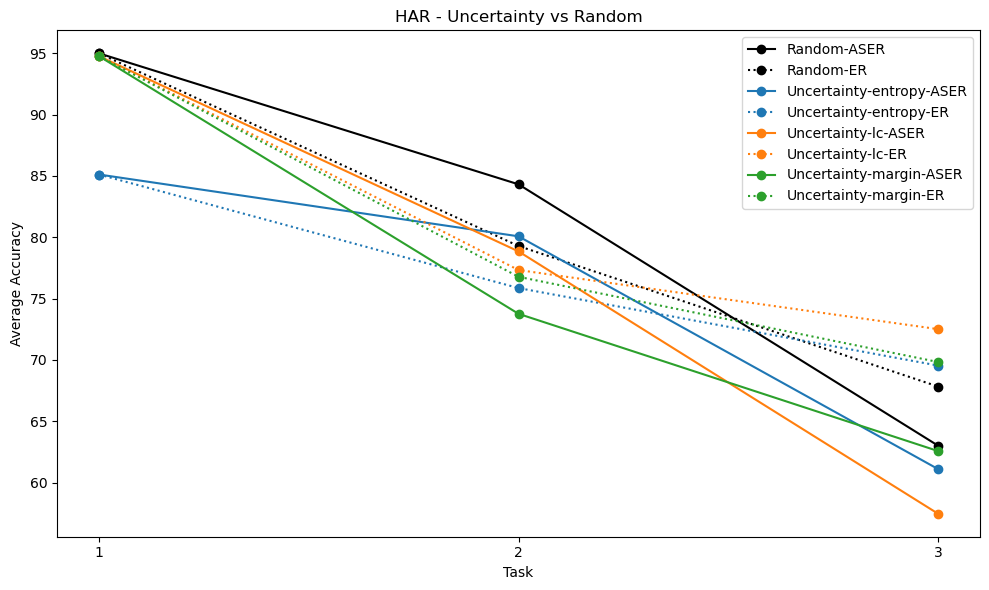

In [19]:
pu.plot_progress(
    df=uncer_aa_task,
    loc = 'upper right',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Average Accuracy")

In [20]:
uncer_la_task = pu.task_level_filter(uncert_la)
uncer_la_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,cycle,task,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,2,0,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
1,2,1,91.38,93.55,92.95,91.71,94.55,89.28,90.97,95.57
2,2,2,92.54,87.94,90.88,89.13,91.96,88.21,89.40,92.53


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


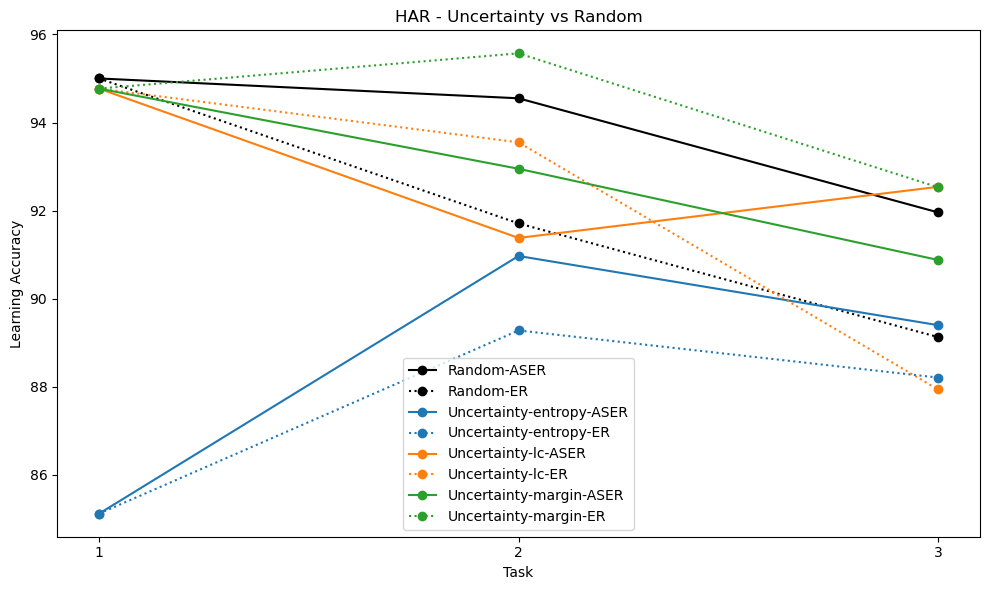

In [21]:
pu.plot_progress(
    df=uncer_la_task,
    loc = 'lower center',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Learning Accuracy")

In [22]:
pu.add_aser_er_means(uncer_aa_task)
uncer_aa_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.00,95.00,91.55,91.55
1,84.32,79.29,77.56,76.66
2,63.01,67.83,60.38,70.63


In [23]:
pu.add_aser_er_means(uncer_la_task)
uncer_la_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.00,95.00,91.55,91.55
1,94.55,91.71,91.77,92.80
2,91.96,89.13,90.94,89.56


In [ ]:
# Select the relevant columns from each dataframe
aa_cols = uncer_aa_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']]
la_cols = uncer_la_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']]

# Concatenate with keys parameter to create hierarchical columns
result = pd.concat([aa_cols, la_cols], axis=1, keys=['Average Accuracy', 'Learning Accuracy'])

# Add task column at the beginning
result.insert(0, 'task', uncer_aa_task['task'].values)

result.style.apply(pu.highlight_max, axis=1).format(precision=2)

# Diversity-based methods